In [1]:
from astropy.io import fits
import numpy as np
import os

from matplotlib import pyplot as plt

In [106]:
# load image
with fits.open('./mass_scaling_test_v2/euclid_spiral_baseclass_4_img_5.fits') as hdul:
    data = np.stack([hdul[1].data, hdul[2].data, hdul[3].data, hdul[4].data])

data.shape

(4, 150, 150)

In [107]:
# load background

filters = ['VIS', 'NIR_Y', 'NIR_J', 'NIR_H']
backgrounds = []
for filter in filters:
    with fits.open(f'../euclid/cutouts/noise2_250_{filter}.fits') as hdul:
        backgrounds.append(hdul[0].data)

offset = np.random.randint(100, size=2)
backgrounds = np.array(backgrounds)[:, offset[0]:offset[0]+150, offset[1]:offset[1]+150]


backgrounds.shape

(4, 150, 150)

In [110]:
file_names = os.listdir('../euclid/euclid_lens_cutouts/VIS')
real_img = []

chosen_file = np.random.choice(file_names).replace('VIS_', '')

for filter in filters:
    with fits.open(f'../euclid/euclid_lens_cutouts/{filter}/{filter}_{chosen_file}') as hdul:
        real_img.append(hdul[0].data)

real_img = np.array(real_img)
real_img.shape

(4, 150, 150)

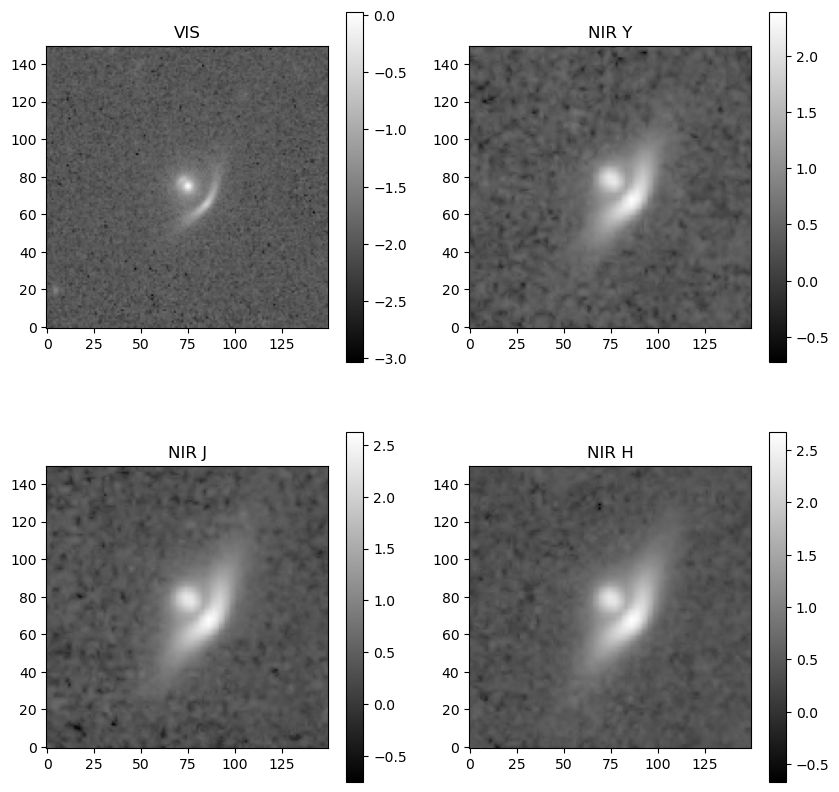

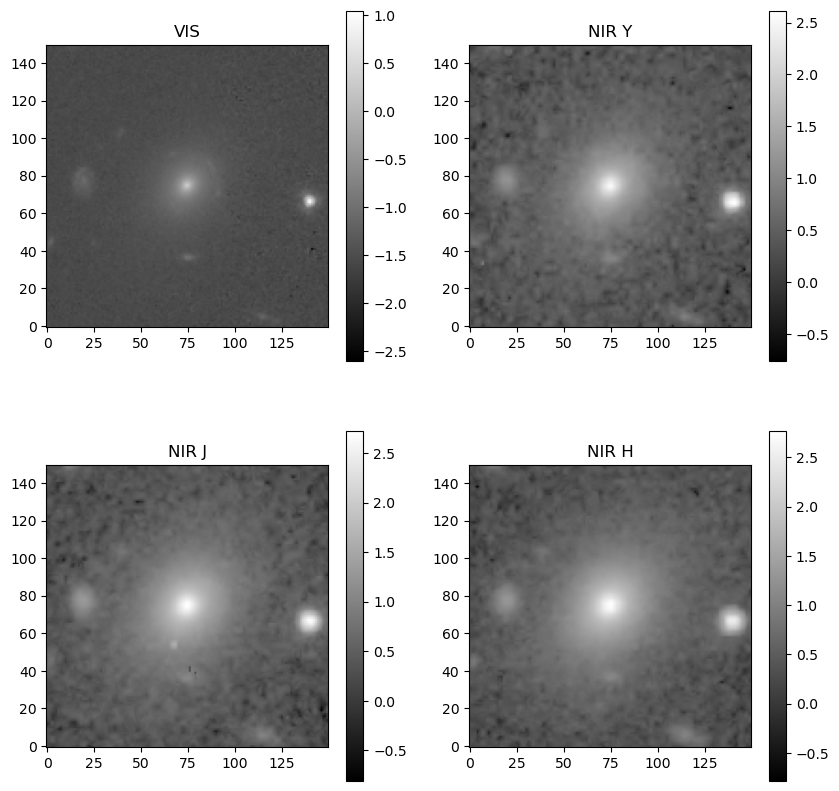

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(np.log10(data[i] + backgrounds[i] - 1.1*np.min(data[i] + backgrounds[i])), cmap='gray', origin='lower')
    ax.set_title(filters[i].replace('_', ' '))
    plt.colorbar(ax.images[0], ax=ax)

plt.show()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(np.log10(real_img[i] - 1.1*np.min(real_img[i])), cmap='gray', origin='lower')
    ax.set_title(filters[i].replace('_', ' '))
    plt.colorbar(ax.images[0], ax=ax)

plt.show()